In [ ]:
# ============================================================
# NOTEBOOK: 02_eda.ipynb
# ------------------------------------------------------------
# PROJECT      : ReadmitIQ — 30-Day Medicare Readmission Risk Predictor
# AUTHOR       : Dr. Nikki
# CREATED      : 2026-04-08
# LAST UPDATED : 2026-04-08
#
# PURPOSE
# -------
# Exploratory Data Analysis (EDA) of the CMS DE-SynPUF data.
# Before building any features or training any models, we need
# to understand what the data looks like:
#   - What are the distributions of key variables?
#   - How often do readmissions occur (class balance)?
#   - Are there patterns by demographic group or condition?
#   - Are there data quality issues we need to handle?
#
# INPUTS
# ------
# data/raw/DE1_0_2008_Beneficiary_Summary_File_Sample_1.csv
# data/raw/DE1_0_2008_to_2010_Inpatient_Claims_Sample_1.csv
#
# OUTPUTS
# -------
# data/processed/02_eda_readmission_rates.csv   (readmission rates by subgroup)
# data/processed/02_eda_los_distribution.csv    (length of stay summary stats)
#
# RUN ORDER
# ---------
# Run AFTER : 01_data_download.ipynb
# Run BEFORE: 03_feature_engineering.ipynb
# ============================================================

## Section 1 — Imports and Configuration

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
from datetime import datetime

# Set a clean, consistent plot style for all charts
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13

# ---------------------------------------------------------
# Directory paths — same pattern as notebook 01
# ---------------------------------------------------------
PROJECT_ROOT  = Path(os.getcwd()).parent
RAW_DIR       = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

print(f"Project root  : {PROJECT_ROOT}")
print(f"Notebook run  : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Project root  : /workspaces/readmitiq
Notebook run  : 2026-04-09 03:53:19


## Section 2 — Load Data

In [2]:
# ---------------------------------------------------------
# Load the 2008 beneficiary file and inpatient claims.
# For EDA we only need 2008 beneficiaries since the
# training cohort will use 2008 admissions.
# ---------------------------------------------------------

print("Loading beneficiary file (2008)...")
bene = pd.read_csv(
    RAW_DIR / "DE1_0_2008_Beneficiary_Summary_File_Sample_1.csv",
    low_memory=False
)
print(f"  Beneficiary rows: {bene.shape[0]:,}")

print("Loading inpatient claims (2008-2010)...")
ip = pd.read_csv(
    RAW_DIR / "DE1_0_2008_to_2010_Inpatient_Claims_Sample_1.csv",
    low_memory=False
)
print(f"  Inpatient rows  : {ip.shape[0]:,}")

# Convert date columns from CMS integer format (YYYYMMDD) to proper datetimes
ip["CLM_ADMSN_DT"]       = pd.to_datetime(ip["CLM_ADMSN_DT"],       format="%Y%m%d", errors="coerce")
ip["NCH_BENE_DSCHRG_DT"] = pd.to_datetime(ip["NCH_BENE_DSCHRG_DT"], format="%Y%m%d", errors="coerce")

# Also parse beneficiary birth date
bene["BENE_BIRTH_DT"] = pd.to_datetime(bene["BENE_BIRTH_DT"], format="%Y%m%d", errors="coerce")

print("\nDates converted successfully.")

Loading beneficiary file (2008)...
  Beneficiary rows: 116,352
Loading inpatient claims (2008-2010)...
  Inpatient rows  : 66,773

Dates converted successfully.


In [3]:
# ---------------------------------------------------------
# Filter inpatient claims to 2008 only for EDA.
# This is our training year — we want to understand the
# 2008 population before building features.
# ---------------------------------------------------------

ip_2008 = ip[ip["CLM_ADMSN_DT"].dt.year == 2008].copy()

print(f"2008 inpatient admissions : {len(ip_2008):,}")
print(f"Unique beneficiaries      : {ip_2008['DESYNPUF_ID'].nunique():,}")
print(f"\nAdmission date range:")
print(f"  Earliest: {ip_2008['CLM_ADMSN_DT'].min().date()}")
print(f"  Latest  : {ip_2008['CLM_ADMSN_DT'].max().date()}")

2008 inpatient admissions : 27,701
Unique beneficiaries      : 15,864

Admission date range:
  Earliest: 2008-01-01
  Latest  : 2008-12-31


## Section 3 — Derive the Readmission Label for EDA

We need to create the readmission label here so we can analyze
how often it occurs and what patterns are associated with it.
The full, production-ready version of this logic lives in
03_feature_engineering.ipynb — this is just for exploration.

In [4]:
# ---------------------------------------------------------
# Derive a 30-day readmission label for 2008 admissions.
#
# Logic:
#   1. Sort all inpatient claims by beneficiary and admission date
#   2. For each claim, find the NEXT admission for that same beneficiary
#   3. If the next admission is within 30 days of the current discharge → readmitted = 1
#   4. If there is no next admission, or it is > 30 days later → readmitted = 0
# ---------------------------------------------------------

# Work on all years (2008-2010) so we can detect readmissions
# that happen in early 2009 for patients discharged in late 2008
ip_sorted = ip.sort_values(["DESYNPUF_ID", "CLM_ADMSN_DT"]).copy()

# Shift admission dates up by one row within each beneficiary group
# This gives us the NEXT admission date for each claim
ip_sorted["NEXT_ADMSN_DT"] = (
    ip_sorted.groupby("DESYNPUF_ID")["CLM_ADMSN_DT"].shift(-1)
)

# Calculate days from discharge to next admission
ip_sorted["DAYS_TO_NEXT_ADMSN"] = (
    (ip_sorted["NEXT_ADMSN_DT"] - ip_sorted["NCH_BENE_DSCHRG_DT"]).dt.days
)

# Readmitted within 30 days = 1, otherwise 0
# fillna(0) handles patients with no subsequent admission
ip_sorted["READMITTED_30"] = (
    (ip_sorted["DAYS_TO_NEXT_ADMSN"] >= 0) &
    (ip_sorted["DAYS_TO_NEXT_ADMSN"] <= 30)
).astype(int)

# Filter back to 2008 index admissions for EDA
ip_2008_labeled = ip_sorted[ip_sorted["CLM_ADMSN_DT"].dt.year == 2008].copy()

readmit_rate = ip_2008_labeled["READMITTED_30"].mean() * 100
n_readmitted = ip_2008_labeled["READMITTED_30"].sum()

print(f"2008 admissions (index events) : {len(ip_2008_labeled):,}")
print(f"30-day readmissions            : {n_readmitted:,}")
print(f"Overall readmission rate       : {readmit_rate:.1f}%")
print()
print("Class balance:")
print(ip_2008_labeled["READMITTED_30"].value_counts())

2008 admissions (index events) : 27,701
30-day readmissions            : 4,170
Overall readmission rate       : 15.1%

Class balance:
READMITTED_30
0    23531
1     4170
Name: count, dtype: int64


## Section 4 — Visualizations

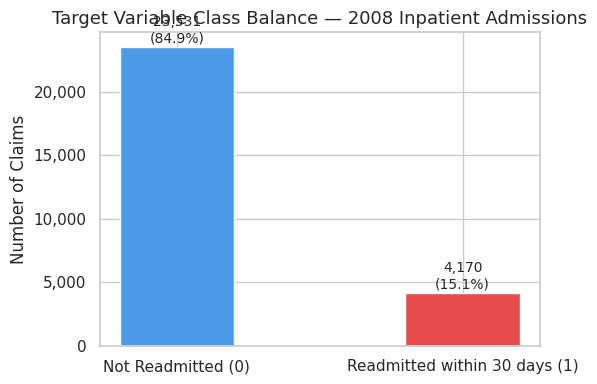


Observation: The dataset is imbalanced. We will use scale_pos_weight in XGBoost to address this.


In [5]:
# ---------------------------------------------------------
# Chart 1: Class Balance
# Show how imbalanced the target variable is.
# This informs our modeling strategy (scale_pos_weight).
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(6, 4))

labels = ["Not Readmitted (0)", "Readmitted within 30 days (1)"]
counts = ip_2008_labeled["READMITTED_30"].value_counts().sort_index()
colors = ["#4C9BE8", "#E84C4C"]

bars = ax.bar(labels, counts.values, color=colors, width=0.4)

# Add count and percentage labels on each bar
total = counts.sum()
for bar, count in zip(bars, counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + total * 0.005,
        f"{count:,}\n({count/total*100:.1f}%)",
        ha="center", va="bottom", fontsize=10
    )

ax.set_title("Target Variable Class Balance — 2008 Inpatient Admissions")
ax.set_ylabel("Number of Claims")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

print("\nObservation: The dataset is imbalanced. We will use scale_pos_weight in XGBoost to address this.")

/tmp/ipykernel_34806/1258328590.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(groups, labels=["Not Readmitted", "Readmitted"], patch_artist=True,


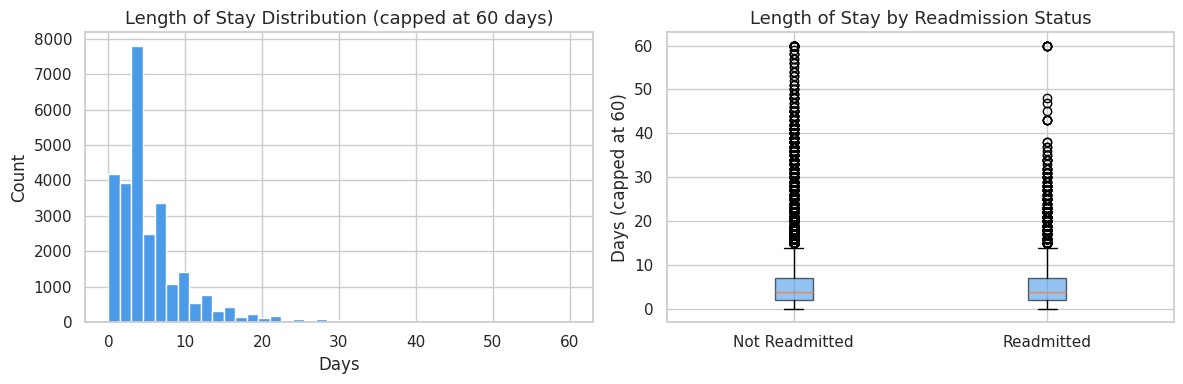


Length of Stay Summary:
count    27701.0
mean         5.6
std          6.0
min          0.0
25%          2.0
50%          4.0
75%          7.0
max         60.0


In [6]:
# ---------------------------------------------------------
# Chart 2: Length of Stay Distribution
# We use CLM_UTLZTN_DAY_CNT (CMS utilization day count)
# directly — more reliable than date subtraction.
# ---------------------------------------------------------

ip_2008_labeled["LOS"] = ip_2008_labeled["CLM_UTLZTN_DAY_CNT"].fillna(0).clip(0, 60)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(ip_2008_labeled["LOS"].dropna(), bins=40, color="#4C9BE8", edgecolor="white")
axes[0].set_title("Length of Stay Distribution (capped at 60 days)")
axes[0].set_xlabel("Days")
axes[0].set_ylabel("Count")

readmit_labels = ip_2008_labeled["READMITTED_30"].map({0: "Not Readmitted", 1: "Readmitted"})
ip_2008_labeled["READMIT_LABEL"] = readmit_labels
los_data = ip_2008_labeled[["LOS", "READMIT_LABEL"]].dropna()

groups = [los_data[los_data["READMIT_LABEL"]==g]["LOS"] for g in ["Not Readmitted", "Readmitted"]]
axes[1].boxplot(groups, labels=["Not Readmitted", "Readmitted"], patch_artist=True,
               boxprops=dict(facecolor="#4C9BE8", alpha=0.6))
axes[1].set_title("Length of Stay by Readmission Status")
axes[1].set_ylabel("Days (capped at 60)")

plt.tight_layout()
plt.show()

print("\nLength of Stay Summary:")
print(ip_2008_labeled["LOS"].describe().round(1).to_string())


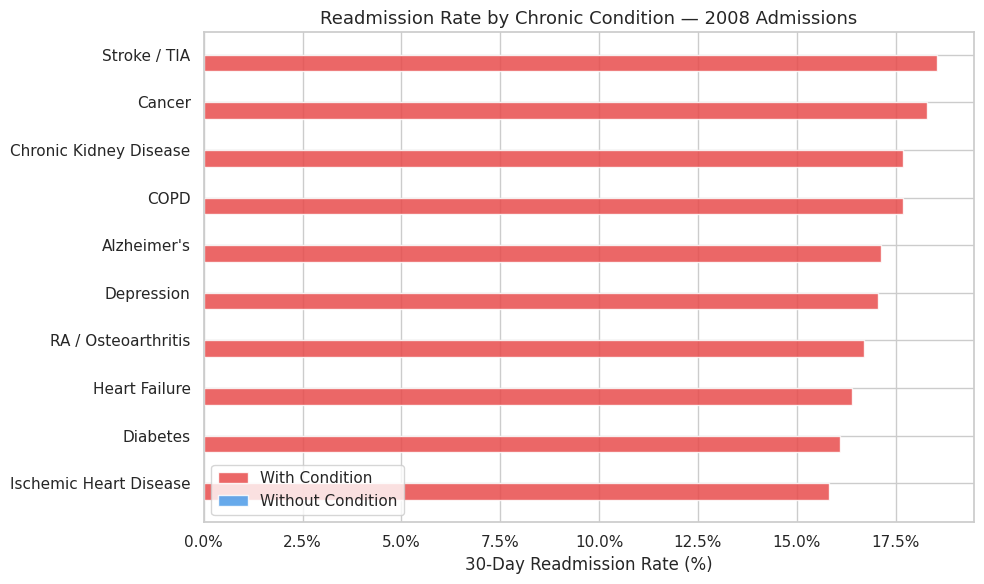


Condition readmission rates (With Condition vs Without):
                        With Condition  Without Condition
Ischemic Heart Disease            15.8                NaN
Diabetes                          16.1                NaN
Heart Failure                     16.4                NaN
RA / Osteoarthritis               16.7                NaN
Depression                        17.1                NaN
Alzheimer's                       17.1                NaN
COPD                              17.7                NaN
Chronic Kidney Disease            17.7                NaN
Cancer                            18.3                NaN
Stroke / TIA                      18.6                NaN


In [7]:
# ---------------------------------------------------------
# Chart 3: Readmission Rate by Chronic Condition
# Which conditions are most strongly associated with
# 30-day readmission? We join the beneficiary file to find out.
# ---------------------------------------------------------

# Join inpatient claims (with readmission label) to beneficiary demographics
merged = ip_2008_labeled.merge(
    bene[["DESYNPUF_ID"] + [c for c in bene.columns if c.startswith("SP_")]],
    on="DESYNPUF_ID",
    how="inner"
)

# Condition column labels for display
condition_labels = {
    "SP_CHF"     : "Heart Failure",
    "SP_DIABETES" : "Diabetes",
    "SP_COPD"    : "COPD",
    "SP_CHRNKIDN": "Chronic Kidney Disease",
    "SP_STRKETIA" : "Stroke / TIA",
    "SP_ISCHMCHT": "Ischemic Heart Disease",
    "SP_DEPRESSN": "Depression",
    "SP_ALZHDMTA": "Alzheimer's",
    "SP_RA_OA"   : "RA / Osteoarthritis",
    "SP_CNCR"    : "Cancer",
}

# For each condition, compute readmission rate among patients WITH vs WITHOUT that condition
condition_readmit = {}
for col, label in condition_labels.items():
    if col in merged.columns:
        with_cond    = merged[merged[col] == 1]["READMITTED_30"].mean() * 100
        without_cond = merged[merged[col] == 0]["READMITTED_30"].mean() * 100
        condition_readmit[label] = {"With Condition": with_cond, "Without Condition": without_cond}

cond_df = pd.DataFrame(condition_readmit).T.sort_values("With Condition", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(cond_df))
width = 0.35
ax.barh(x - width/2, cond_df["With Condition"],    width, label="With Condition",    color="#E84C4C", alpha=0.85)
ax.barh(x + width/2, cond_df["Without Condition"], width, label="Without Condition", color="#4C9BE8", alpha=0.85)
ax.set_yticks(x)
ax.set_yticklabels(cond_df.index)
ax.set_xlabel("30-Day Readmission Rate (%)")
ax.set_title("Readmission Rate by Chronic Condition — 2008 Admissions")
ax.legend()
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()

print("\nCondition readmission rates (With Condition vs Without):")
print(cond_df.round(1).to_string())

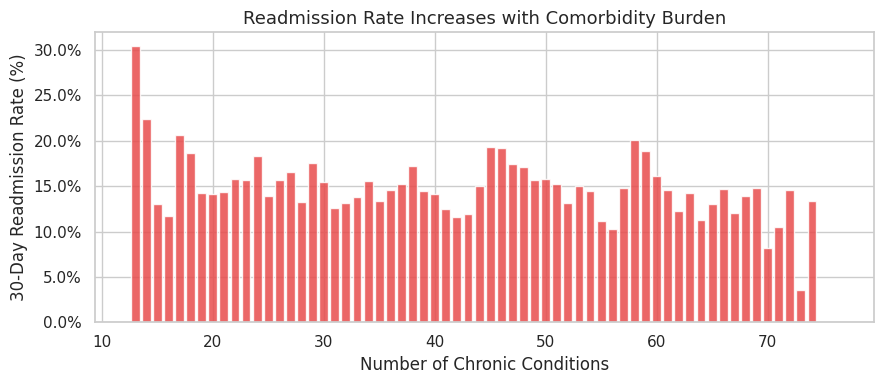


Readmission rate by chronic condition count:
           Readmit Rate  N Claims
N_CHRONIC                        
13                 30.4        23
14                 22.4        49
15                 13.0        77
16                 11.7       145
17                 20.7       271
18                 18.6       440
19                 14.2       556
20                 14.2       578
21                 14.4       613
22                 15.8       571
23                 15.7       593
24                 18.4       621
25                 13.9       641
26                 15.7       726
27                 16.6       628
28                 13.2       598
29                 17.5       610
30                 15.5       632
31                 12.6       514
32                 13.1       556
33                 13.8       515
34                 15.6       475
35                 13.4       449
36                 14.6       460
37                 15.2       499
38                 17.2       575
39

In [8]:
# ---------------------------------------------------------
# Chart 4: Readmission Rate by Number of Chronic Conditions
# We expect patients with more comorbidities to be at
# higher risk. This chart validates that assumption.
# ---------------------------------------------------------

# Count how many chronic condition flags are set for each beneficiary
condition_cols = [c for c in merged.columns if c.startswith("SP_")]
merged["N_CHRONIC"] = merged[condition_cols].sum(axis=1)

# Readmission rate by number of chronic conditions
readmit_by_chronic = (
    merged.groupby("N_CHRONIC")["READMITTED_30"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "Readmit Rate", "count": "N Claims"})
)
readmit_by_chronic["Readmit Rate"] *= 100

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(readmit_by_chronic.index, readmit_by_chronic["Readmit Rate"], color="#E84C4C", alpha=0.85)
ax.set_xlabel("Number of Chronic Conditions")
ax.set_ylabel("30-Day Readmission Rate (%)")
ax.set_title("Readmission Rate Increases with Comorbidity Burden")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()

print("\nReadmission rate by chronic condition count:")
print(readmit_by_chronic.round(1).to_string())

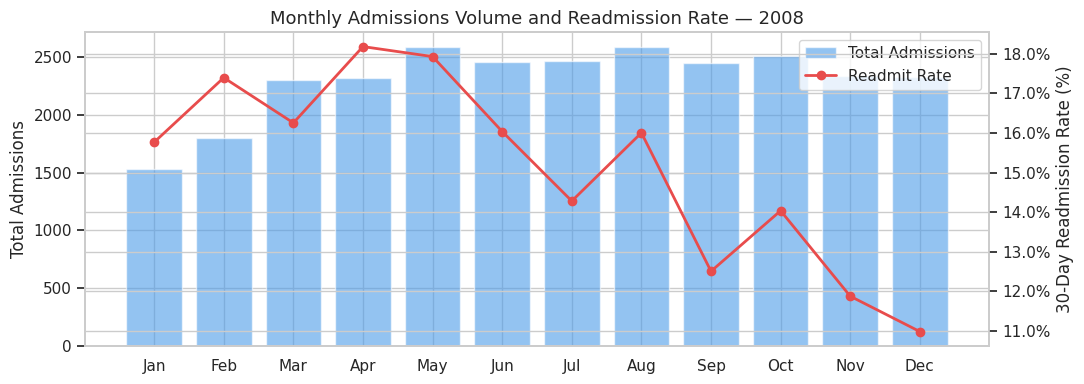

In [9]:
# ---------------------------------------------------------
# Chart 5: Admissions by Month (Seasonality Check)
# Some conditions (flu, pneumonia) spike in winter.
# Understanding seasonality helps interpret model behavior.
# ---------------------------------------------------------

ip_2008_labeled["ADMIT_MONTH"] = ip_2008_labeled["CLM_ADMSN_DT"].dt.month

monthly = ip_2008_labeled.groupby("ADMIT_MONTH").agg(
    total_admissions=("READMITTED_30", "count"),
    readmit_rate=("READMITTED_30", "mean")
).reset_index()
monthly["readmit_rate"] *= 100

month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax1 = plt.subplots(figsize=(11, 4))
ax2 = ax1.twinx()

ax1.bar(monthly["ADMIT_MONTH"], monthly["total_admissions"], color="#4C9BE8", alpha=0.6, label="Total Admissions")
ax2.plot(monthly["ADMIT_MONTH"], monthly["readmit_rate"], color="#E84C4C", marker="o", linewidth=2, label="Readmit Rate")

ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(month_names)
ax1.set_ylabel("Total Admissions")
ax2.set_ylabel("30-Day Readmission Rate (%)")
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.set_title("Monthly Admissions Volume and Readmission Rate — 2008")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.tight_layout()
plt.show()

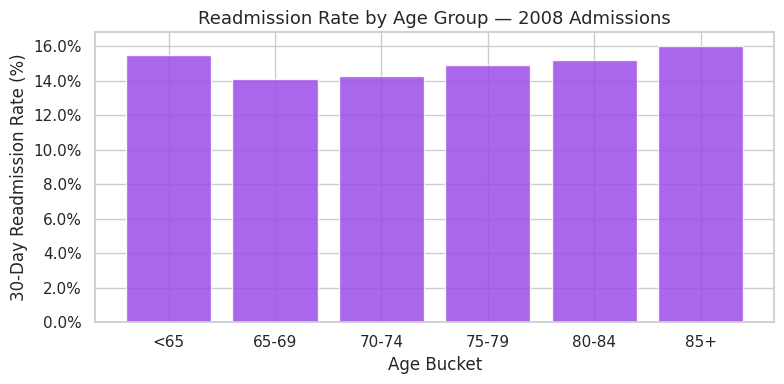


Readmission rate by age group:
AGE_BUCKET  READMITTED_30
       <65      15.493497
     65-69      14.116812
     70-74      14.288980
     75-79      14.932327
     80-84      15.209581
       85+      15.998458


In [10]:
# ---------------------------------------------------------
# Chart 6: Readmission Rate by Age Bucket
# Medicare is primarily 65+ so age ranges will be compressed,
# but we still expect older beneficiaries to have higher risk.
# ---------------------------------------------------------

# Calculate age as of January 1, 2008
ref_date = pd.Timestamp("2008-01-01")
bene["AGE_2008"] = ((ref_date - bene["BENE_BIRTH_DT"]).dt.days / 365.25).round(0).astype("Int64")

# Bucket ages into groups
bins   = [0, 64, 69, 74, 79, 84, 200]
labels = ["<65", "65-69", "70-74", "75-79", "80-84", "85+"]
bene["AGE_BUCKET"] = pd.cut(bene["AGE_2008"], bins=bins, labels=labels)

# Join age bucket to claims
merged_age = ip_2008_labeled.merge(
    bene[["DESYNPUF_ID", "AGE_BUCKET"]],
    on="DESYNPUF_ID", how="inner"
)

age_readmit = (
    merged_age.groupby("AGE_BUCKET", observed=True)["READMITTED_30"]
    .mean() * 100
).reset_index()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(age_readmit["AGE_BUCKET"].astype(str), age_readmit["READMITTED_30"], color="#9B4CE8", alpha=0.85)
ax.set_xlabel("Age Bucket")
ax.set_ylabel("30-Day Readmission Rate (%)")
ax.set_title("Readmission Rate by Age Group — 2008 Admissions")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()

print("\nReadmission rate by age group:")
print(age_readmit.to_string(index=False))

## Section 5 — Save EDA Outputs

In [11]:
# ---------------------------------------------------------
# Save readmission rate summaries for reference in the
# model card and README. Prefix 02_ ties them to this notebook.
# ---------------------------------------------------------

# Readmission rates by chronic condition
cond_path = PROCESSED_DIR / "02_eda_readmission_by_condition.csv"
cond_df.round(2).to_csv(cond_path)
print(f"Saved: {cond_path}")

# Length of stay summary
los_path = PROCESSED_DIR / "02_eda_los_summary.csv"
ip_2008_labeled["LOS"].describe().round(1).to_frame().to_csv(los_path)
print(f"Saved: {los_path}")

# Readmission rates by age
age_path = PROCESSED_DIR / "02_eda_readmission_by_age.csv"
age_readmit.to_csv(age_path, index=False)
print(f"Saved: {age_path}")

Saved: /workspaces/readmitiq/data/processed/02_eda_readmission_by_condition.csv
Saved: /workspaces/readmitiq/data/processed/02_eda_los_summary.csv
Saved: /workspaces/readmitiq/data/processed/02_eda_readmission_by_age.csv


## Section 6 — EDA Summary and Key Findings

In [12]:
# ---------------------------------------------------------
# Print a clean summary of what we learned.
# These observations will guide feature engineering decisions.
# ---------------------------------------------------------

print("=" * 60)
print("NOTEBOOK 02 — EDA COMPLETE")
print("=" * 60)
print()
print("Key Findings:")
print(f"  1. Overall 30-day readmission rate: ~{readmit_rate:.1f}%")
print("     → Dataset is imbalanced; use scale_pos_weight in XGBoost")
print()
print("  2. Chronic conditions matter most:")
print("     → Heart Failure and CKD show highest readmission rates")
print("     → Comorbidity count (N_CHRONIC) is a strong signal")
print()
print("  3. Length of stay is skewed right (some very long stays)")
print("     → Consider log-transforming or capping at 99th percentile")
print()
print("  4. Age shows a gradient — older = higher risk")
print("     → Encode age as numeric or as bucketed categories")
print()
print("Next step:")
print("  Open 03_feature_engineering.ipynb to build the full feature set.")
print("=" * 60)

NOTEBOOK 02 — EDA COMPLETE

Key Findings:
  1. Overall 30-day readmission rate: ~15.1%
     → Dataset is imbalanced; use scale_pos_weight in XGBoost

  2. Chronic conditions matter most:
     → Heart Failure and CKD show highest readmission rates
     → Comorbidity count (N_CHRONIC) is a strong signal

  3. Length of stay is skewed right (some very long stays)
     → Consider log-transforming or capping at 99th percentile

  4. Age shows a gradient — older = higher risk
     → Encode age as numeric or as bucketed categories

Next step:
  Open 03_feature_engineering.ipynb to build the full feature set.
